# La separación, paso a paso

**Objetivo.** Presentar con cuidado la tabla de la jerarquía
$U^{\text{single}} \le U^s_{NO} \le U^s_{O} \le U^D \le U^D_A \le U^{\max}$
y, sobre todo, el eslabón nuevo $U^D \le U^D_A$: el valor de contar.

**Cómo leerlo.** No empezamos por la tabla. Subimos en cuatro capas: primero el
mecanismo en una sola instancia, luego la jerarquía completa de esa instancia,
luego el promedio como una cascada de aportes, y al final el crecimiento del
beneficio con la escala. La tabla agregada va al cierre, ya entendida.

**Procedencia.** Todo se regenera aquí desde `hierarchy_experiment.py` (código
corregido) y los CSV por instancia en `results/hierarchy/`. No hay números
escritos a mano.


In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

import augmented
ROOT = os.path.dirname(os.path.dirname(os.path.abspath(augmented.__file__)))

from augmented.core import mask_from_indices
from augmented.bayesian import bayesian_update_by_counting
from augmented.hierarchy_experiment import hierarchy_for_instance, CHAIN

print('repo root:', ROOT)
print('cadena:', ' <= '.join(CHAIN))

repo root: /Users/hectorbecerrilvillamil/Desktop/PooledTesting/pooled-testing-dynamic
cadena: U_single <= U_s_NO <= U_s_O <= U_D <= U_D_A <= U_max


## Capa 1a — El mecanismo: el conteo deduce lo que el binario no

Antes de medir el promedio, conviene ver de dónde nace la ventaja. Tres personas,
dos tests: $\{0,1\}=1$ y $\{1,2\}=0$. Del segundo se sabe que 1 y 2 están sanos;
sustituyendo en el primero, el único infectado de $\{0,1\}$ tiene que ser 0. El
conteo deduce con certeza el estado de 0 sin haberlo testeado solo. El binario, al
solo decir positivo o negativo, pierde esa aritmética cuando hay conteos
intermedios.

In [2]:
p = [0.3, 0.3, 0.3]
historia = ((mask_from_indices([0, 1]), 1), (mask_from_indices([1, 2]), 0))
post = bayesian_update_by_counting(p, historia, 3)
print('prior  P(infectado) :', p)
print('tests              : {0,1}=1 , {1,2}=0')
print('posterior          :', [round(x, 3) for x in post])
print()
print('Lectura: 1 y 2 quedan sanos (0.0) y 0 queda infectado con certeza (1.0),')
print('deducido solo por la aritmetica de los conteos.')

prior  P(infectado) : [0.3, 0.3, 0.3]
tests              : {0,1}=1 , {1,2}=0
posterior          : [1.0, 0.0, 0.0]

Lectura: 1 y 2 quedan sanos (0.0) y 0 queda infectado con certeza (1.0),
deducido solo por la aritmetica de los conteos.


## Capa 1b — La jerarquía en una sola instancia

Ahora la cadena completa para una instancia concreta. Buscamos, entre varias
instancias chicas, la de mayor brecha $U^D_A - U^D$ para que el eslabón del conteo
se vea, y mostramos sus seis valores como una escalera. Cada peldaño agrega un
poder: juntar muestras, solapar, adaptar y, el nuevo, contar.

In [3]:
rng = np.random.default_rng(7)
N, B, G = 5, 3, 5
mejor = None
for _ in range(40):
    p = rng.uniform(0.0, 1.0, size=N).tolist()
    u = rng.choice([1.0, 2.0, 3.0], size=N).tolist()
    h = hierarchy_for_instance(p, u, B, G)
    gap = h['U_D_A'] - h['U_D']
    if mejor is None or gap > mejor[0]:
        mejor = (gap, p, u, h)

gap, p, u, h = mejor
print(f'instancia elegida (N={N}, B={B}, G={G}), brecha U_D_A - U_D = {gap:.4f}')
print('p =', [round(x, 3) for x in p])
print('u =', u)
for k in CHAIN:
    print(f'  {k:10s} = {h[k]:.4f}')

instancia elegida (N=5, B=3, G=5), brecha U_D_A - U_D = 0.5402
p = [0.344, 0.59, 0.684, 0.355, 0.519]
u = [2.0, 3.0, 3.0, 3.0, 3.0]
  U_single   = 4.6880
  U_s_NO     = 4.7854
  U_s_O      = 4.7854
  U_D        = 4.7891
  U_D_A      = 5.3294
  U_max      = 6.8661


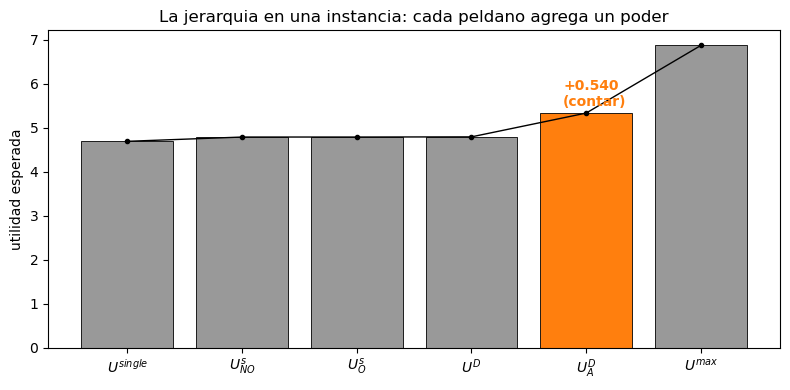

In [4]:
vals = [h[k] for k in CHAIN]
etiquetas = [r'$U^{single}$', r'$U^s_{NO}$', r'$U^s_O$',
             r'$U^D$', r'$U^D_A$', r'$U^{max}$']
colores = ['0.6'] * len(CHAIN)
colores[CHAIN.index('U_D_A')] = 'tab:orange'  # el peldaño del conteo

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(vals)), vals, color=colores, edgecolor='k', linewidth=0.6)
ax.plot(range(len(vals)), vals, 'k.-', lw=1)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(etiquetas)
ax.set_ylabel('utilidad esperada')
ax.set_title('La jerarquia en una instancia: cada peldano agrega un poder')
ax.annotate(f'+{gap:.3f}\n(contar)',
            xy=(CHAIN.index('U_D_A'), h['U_D_A']),
            xytext=(CHAIN.index('U_D_A') - 0.2, h['U_D_A'] + 0.15),
            color='tab:orange', fontweight='bold')
plt.tight_layout(); plt.show()

## Capa 2 — El promedio como cascada de aportes

Pasamos al promedio sobre muchas instancias. En vez de la tabla, una cascada: cada
barra es cuánto bienestar agrega cada capacidad respecto a la anterior. Así la
pregunta "¿cuánto vale contar?" se responde de un vistazo: es el alto de la barra
naranja $U^D_A - U^D$.

In [5]:
df = pd.concat([
    pd.read_csv(os.path.join(ROOT, 'results/hierarchy/hierarchy_small.csv')),
    pd.read_csv(os.path.join(ROOT, 'results/hierarchy/hierarchy_n7.csv')),
], ignore_index=True)
df['benefit_pct'] = (df['U_D_A'] - df['U_D']) / df['U_D'] * 100.0
print('instancias por configuracion:')
print(df.groupby(['N', 'B', 'G']).size())

instancias por configuracion:
N  B  G
3  2  3    200
5  3  5    200
7  3  7     40
dtype: int64


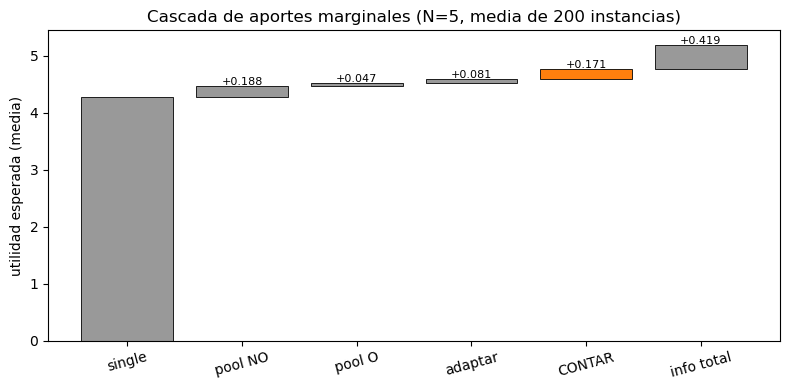

El aporte de CONTAR (U_D_A - U_D) es 0.1707 en media.


In [6]:
N_show = 5
m = df[df['N'] == N_show][CHAIN].mean()
incrementos = [m[CHAIN[0]]] + [m[CHAIN[i]] - m[CHAIN[i-1]]
                               for i in range(1, len(CHAIN))]
etiquetas = ['single', 'pool NO', 'pool O', 'adaptar', 'CONTAR', 'info total']
colores = ['0.6'] * len(CHAIN); colores[4] = 'tab:orange'

fig, ax = plt.subplots(figsize=(8, 4))
base = 0.0
for i, inc in enumerate(incrementos):
    ax.bar(i, inc, bottom=base, color=colores[i], edgecolor='k', linewidth=0.6)
    if i > 0:
        ax.text(i, base + inc + 0.02, f'+{inc:.3f}', ha='center', fontsize=8)
    base += inc
ax.set_xticks(range(len(CHAIN))); ax.set_xticklabels(etiquetas, rotation=15)
ax.set_ylabel('utilidad esperada (media)')
ax.set_title(f'Cascada de aportes marginales (N={N_show}, media de '
             f'{int((df.N==N_show).sum())} instancias)')
plt.tight_layout(); plt.show()
print(f'El aporte de CONTAR (U_D_A - U_D) es {incrementos[4]:.4f} en media.')

## Capa 3 — El beneficio del conteo crece con la escala

La historia central. Para cada $N$ calculamos el beneficio relativo
$(U^D_A - U^D)/U^D$ instancia por instancia, y graficamos su media con barras de
error estándar. Que la línea suba es la evidencia del mecanismo: el conteo paga vía
mejores posteriores sobre un horizonte más largo, así que su valor crece con la
población y el presupuesto.

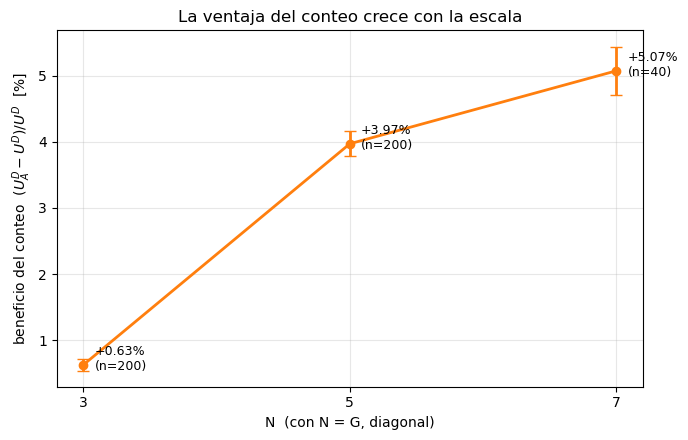

N
3    0.628
5    3.969
7    5.072
Name: benefit_pct, dtype: float64


In [7]:
g = df.groupby('N')['benefit_pct']
Ns = sorted(df['N'].unique())
medias = g.mean().reindex(Ns)
sems = g.sem().reindex(Ns)
counts = g.count().reindex(Ns)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(Ns, medias.values, yerr=sems.values, marker='o', capsize=4,
            color='tab:orange', lw=2)
for x, y, c in zip(Ns, medias.values, counts.values):
    ax.annotate(f'+{y:.2f}%\n(n={int(c)})', (x, y),
                textcoords='offset points', xytext=(8, -4), fontsize=9)
ax.set_xlabel('N  (con N = G, diagonal)')
ax.set_ylabel(r'beneficio del conteo  $(U^D_A-U^D)/U^D$  [%]')
ax.set_title('La ventaja del conteo crece con la escala')
ax.set_xticks(Ns); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(medias.round(3))

## Capa 4 — La tabla, ya entendida, y las salvedades

Recién ahora la tabla agregada, que resume lo anterior. Y, para presentarla con
honestidad, las salvedades del montaje experimental, que es lo primero que un
revisor cuidadoso preguntará.

In [8]:
tabla = df.groupby(['N', 'B', 'G'])[CHAIN].mean()
tabla['benefit_%'] = df.groupby(['N', 'B', 'G'])['benefit_pct'].mean()
tabla['n_inst'] = df.groupby(['N', 'B', 'G']).size()
print(tabla.round(4).to_string())

       U_single  U_s_NO   U_s_O     U_D   U_D_A   U_max  benefit_%  n_inst
N B G                                                                     
3 2 3    2.5716  2.6434  2.6587  2.6860  2.7040  2.9920     0.6284     200
5 3 5    4.2841  4.4725  4.5194  4.6000  4.7707  5.1894     3.9693     200
7 3 7    4.9081  5.2486  5.3354  5.4542  5.7174  6.8057     5.0718      40


**Montaje experimental (declararlo sin esconder nada).** Priors
$p_i \sim U(0,1)$ y utilidades $u_i \sim \text{Uniforme}\{1,2,3\}$. Configuraciones
en la diagonal $N=G$, con presupuesto $B$ que crece modestamente. La cadena
$U^{\text{single}} \le \dots \le U^{\max}$ se cumple en todas las instancias (cero
violaciones).

**La salvedad honesta.** $N=3$ y $N=5$ usan 200 instancias, pero $N=7$ solo 40,
porque el DP exacto $U^D_A$ a $N=7$ es caro (el augmented ramifica en $|t|+1$
resultados y enumera perfiles). Por eso su barra de error es más ancha. Antes de
fijar el número de $N=7$ conviene relanzarlo con más instancias o reportar el
intervalo; el código está listo para hacerlo.

**El mensaje, en una frase.** El conteo domina al binario y su valor crece con la
escala, exactamente como predice el mecanismo de mejores posteriores sobre un
horizonte más largo.

## Preguntas para Francisco

Tres ganchos para la discusión. ¿El valor por paso bajo conteo es submodular
adaptativo? De serlo, el greedy heredaría una garantía $1 - 1/e$. ¿Cómo se comporta
esta separación cuando el conteo se observa con ruido, como el cycle threshold real
de la qPCR? ¿Hay clases de diseños de test (disjuntos, laminares, treewidth
acotado) donde la inferencia exacta sea tratable y la separación se pueda
caracterizar en cerrado?